# Introduction to Audio Data Manipulation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://drive.google.com/file/d/1q01X1M23pAU3IbvCUMf3dQaRzwmuHbfh/view?usp=sharing)


# Record Audio From Microphone

In [9]:
import sounddevice as sd
import numpy as np

duration = 3  # seconds
sampling_rate = 16000  # Hz
dtype = np.int16  # bit depth

recording = sd.rec(
    duration * sampling_rate,
    samplerate=sampling_rate,
    channels=1,
    dtype=dtype,
)

print("Recording...")
sd.wait()  # Wait until the recording is finished
print("Recording finished.")

Recording...
Recording finished.


In [10]:
print("audio data shape:", recording.shape)
print(recording[-10:])  # Print the last 10 samples of the recording

audio data shape: (48000, 1)
[[286]
 [253]
 [216]
 [183]
 [146]
 [ 78]
 [ 26]
 [  4]
 [ -8]
 [ -7]]


In [11]:
sd.play(recording, samplerate=sampling_rate)

# Visualize Waveform and Spectrogram

- **Initial Audio Inspection**: Quickly understanding the general structure, such as silent segments, dynamic changes, and start/end points.
- **Anomaly Detection**: Identifying issues like clipping, background noise, or DC offset.

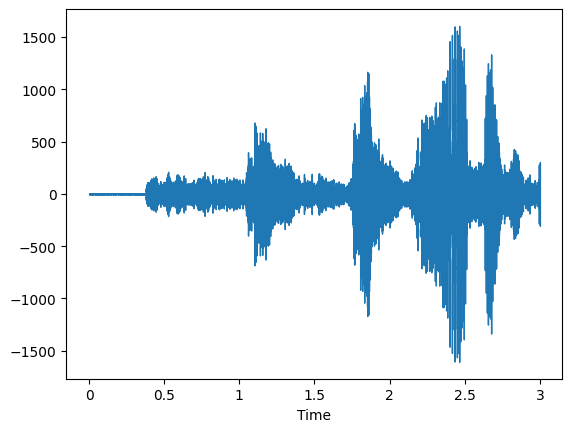

In [12]:
import librosa
import matplotlib.pyplot as plt

librosa.display.waveshow(recording.flatten().astype(np.float32), sr=sampling_rate)

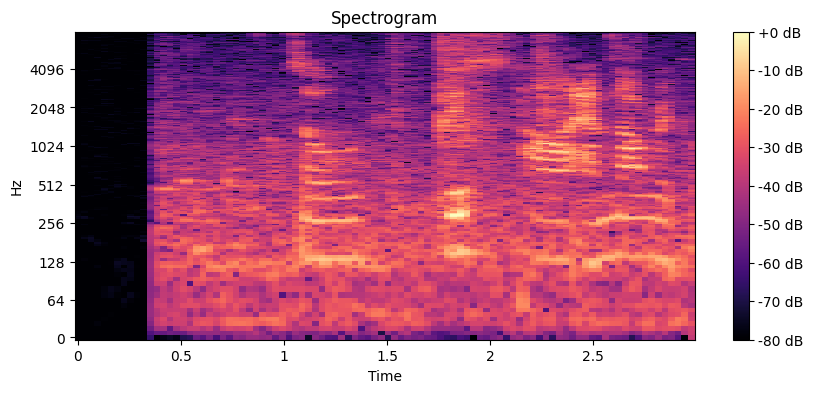

In [13]:
import numpy as np

frequencies = np.abs(librosa.stft(recording.flatten().astype(np.float32)))
D = librosa.amplitude_to_db(frequencies, ref=np.max)  # dBFS
plt.figure(figsize=(10, 4))
librosa.display.specshow(D, sr=sampling_rate, x_axis="time", y_axis="log")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

# Load and Write Audio File

In [34]:
import soundfile as sf

sf.write("recoding.wav", recording, sampling_rate, subtype="PCM_16")

In [35]:
recording, sampling_rate = sf.read("recoding.wav")
print(recording.shape, sampling_rate)

(48000,) 16000


# Resample

In [ ]:
resampled_rate = 44100
resampled_recording = librosa.resample(
    recording.flatten().astype(np.float32),
    orig_sr=sampling_rate,
    target_sr=resampled_rate,
)
print(resampled_recording.shape)

(132300,)


In [17]:
sd.play(resampled_recording, samplerate=resampled_rate)